In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

from MixedEffectsModeling.validation import lobo_mmd

LOBO = Path('./LOBO_Results_mixed')
FIG = LOBO / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

In [13]:
def _p_to_asterisk(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def _short_batch_label(batch):
    name, _, num = batch.replace(' et al.', '').partition('_Batch_')
    return f'{name}_{num}' if num else name


def plot_mmd_bar(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    fig, ax = plt.subplots(figsize=(4, 6))
    bars = ax.bar(range(len(d)), d['mmd2'], color='#00C78B')
    y_span = d['mmd2'].max() - d['mmd2'].min()
    for bar, p in zip(bars, d['perm_p']):
        label = _p_to_asterisk(p)
        if not label:
            continue
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01 * y_span, label, ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('MMD$^2$ (held-out HC vs disease)')
    ax.set_xlabel('LOBO batch')
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig


def plot_mmd_direction(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hlines(y, d['hc_ref_dist'], d['dis_ref_dist'],
             color=np.where(d['disease_farther'], '#00C78B', '#999999'), linewidth=3)
    ax.scatter(d['hc_ref_dist'], y, color='#A4AFB8', label='held-out HC', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.scatter(d['dis_ref_dist'], y, color='#00C78B', label='disease', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Distance from HC reference')
    ax.set_ylabel('LOBO batch')
    ax.legend(frameon=False)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig

In [14]:
# 0. Raw MMD summary (held-out HC vs held-out disease, per Tier-A batch with n_hc >= lobo_mmd.MIN_N_HC)
# no SHASH correction -- Z_test.npy / cv_zscores.pkl are used exactly as scored
df_raw = lobo_mmd.mmd_summary_cached(force=False, shash=False)
print(df_raw.to_string(index=False))

n_sig_raw = int(((df_raw['perm_p'] < 0.05) & df_raw['disease_farther']).sum())
print(f"\n{n_sig_raw}/{len(df_raw)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther
          Ward Z et al._Batch_1   116    224 0.057589 0.000999    136.20541     146.51547             True
           Moore et al._Batch_1    71    173 0.000736 0.224775    138.07010     145.53542             True
Roskams-Hieter B et al._Batch_2    27     58 0.009790 0.036963    141.31291     153.15036             True
       Moufarrej et al._Batch_4    47     39 0.009684 0.058941    127.64932     143.12900             True
            Chen et al._Batch_2    31     32 0.024635 0.011988    136.00629     154.55028             True
       Moufarrej et al._Batch_1    54     23 0.034273 0.002997    127.92324     134.77869             True

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)


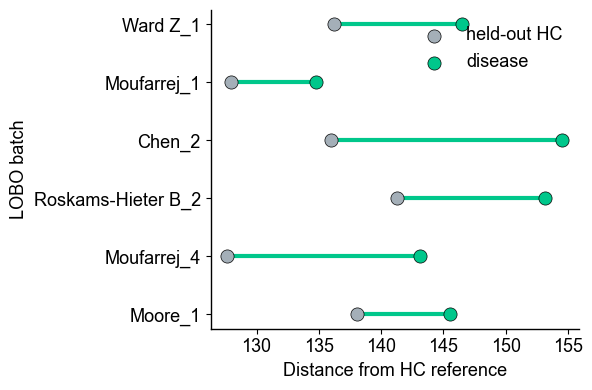

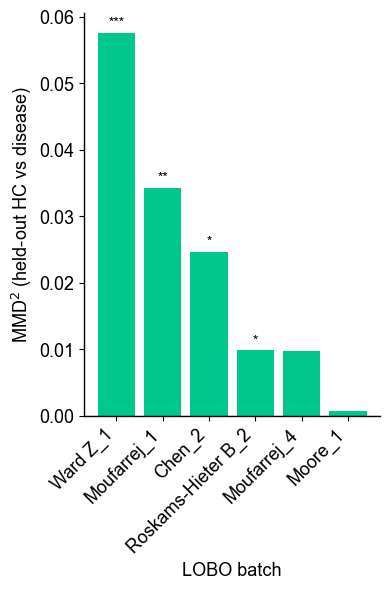

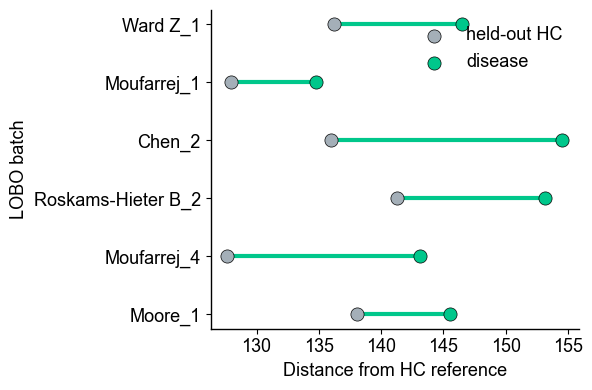

In [15]:
# 1. Raw MMD plots
plot_mmd_bar(df_raw, FIG / 'mmd_bar.png')
plot_mmd_direction(df_raw, FIG / 'mmd_direction.png')

In [16]:
# 2. SHASH-corrected MMD summary -- each gene's already-fit SHASH transform (cv_stats.csv)
# applied to both the LOBO Z and the CV-reference centroid before the comparison
df_shash = lobo_mmd.mmd_summary_cached(force=False, shash=True)
print(df_shash.to_string(index=False))

n_sig_shash = int(((df_shash['perm_p'] < 0.05) & df_shash['disease_farther']).sum())
print(f"\n{n_sig_shash}/{len(df_shash)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther
          Ward Z et al._Batch_1   116    224 0.057589 0.000999    136.20541     146.51547             True
           Moore et al._Batch_1    71    173 0.000736 0.224775    138.07010     145.53542             True
Roskams-Hieter B et al._Batch_2    27     58 0.009790 0.036963    141.31291     153.15036             True
       Moufarrej et al._Batch_4    47     39 0.009684 0.058941    127.64932     143.12900             True
            Chen et al._Batch_2    31     32 0.024635 0.011988    136.00629     154.55028             True
       Moufarrej et al._Batch_1    54     23 0.034273 0.002997    127.92324     134.77869             True

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)


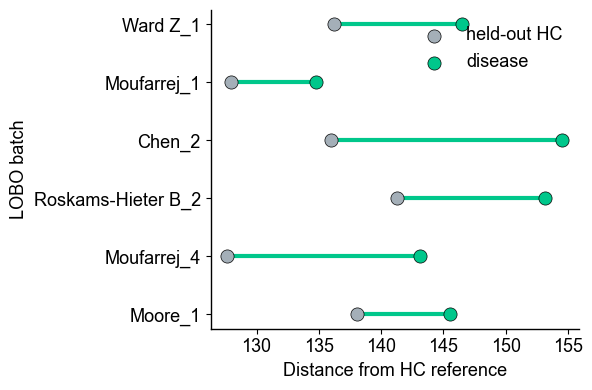

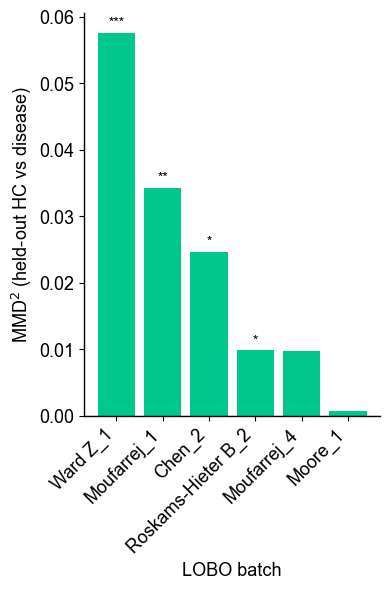

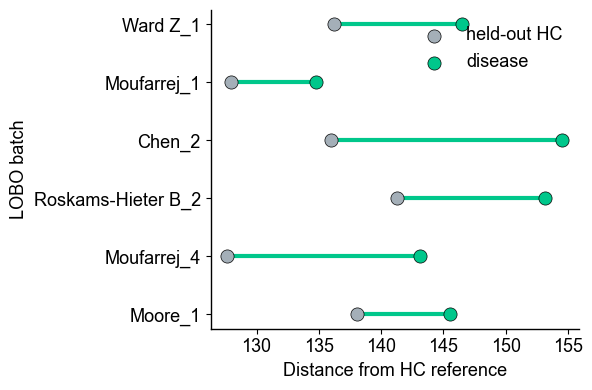

In [17]:
# 3. SHASH-corrected MMD plots
plot_mmd_bar(df_shash, FIG / 'mmd_bar_shash.png')
plot_mmd_direction(df_shash, FIG / 'mmd_direction_shash.png')

In [18]:
# 4. Raw vs SHASH-corrected, side by side -- does the raw-scale call survive de-skewing?
cmp = df_raw.merge(df_shash, on='batch', suffixes=('_raw', '_shash'))
cmp['sig_raw'] = (cmp['perm_p_raw'] < 0.05) & cmp['disease_farther_raw']
cmp['sig_shash'] = (cmp['perm_p_shash'] < 0.05) & cmp['disease_farther_shash']
print(cmp[['batch', 'mmd2_raw', 'perm_p_raw', 'sig_raw', 'mmd2_shash', 'perm_p_shash', 'sig_shash']].to_string(index=False))
print(f"\nagree (both sig or both not): {(cmp['sig_raw'] == cmp['sig_shash']).sum()}/{len(cmp)}")

                          batch  mmd2_raw  perm_p_raw  sig_raw  mmd2_shash  perm_p_shash  sig_shash
          Ward Z et al._Batch_1  0.057589    0.000999     True    0.057589      0.000999       True
           Moore et al._Batch_1  0.000736    0.224775    False    0.000736      0.224775      False
Roskams-Hieter B et al._Batch_2  0.009790    0.036963     True    0.009790      0.036963       True
       Moufarrej et al._Batch_4  0.009684    0.058941    False    0.009684      0.058941      False
            Chen et al._Batch_2  0.024635    0.011988     True    0.024635      0.011988       True
       Moufarrej et al._Batch_1  0.034273    0.002997     True    0.034273      0.002997       True

agree (both sig or both not): 6/6


## 5. OOD-filtered comparison

LOBO already refits per batch, so covariate-extrapolation filtering here is inference-only: `lobo_engine.compute_ood()` fits a `MahalanobisFilter` per batch on that batch's own train-fold HC (every HC sample except the held-out batch -- never the held-out batch itself) and flags held-out test rows whose covariates fall outside it (`ood_mask.npy`). Run once (cheap, no R); re-run only if LOBO is retrained.

In [ ]:
from MixedEffectsModeling.validation.lobo_engine import compute_ood

compute_ood()

In [ ]:
# OOD-filtered MMD, raw and SHASH-corrected
df_ood = lobo_mmd.mmd_summary_cached(force=False, shash=False, ood_filter=True)
df_shash_ood = lobo_mmd.mmd_summary_cached(force=False, shash=True, ood_filter=True)

for label, d in [('ood', df_ood), ('shash+ood', df_shash_ood)]:
    n_sig = int(((d['perm_p'] < 0.05) & d['disease_farther']).sum())
    print(f"[{label}] {n_sig}/{len(d)} batches significant (p<0.05) AND disease farther")
print()
print(df_shash_ood.to_string(index=False))

In [ ]:
# shash+ood plots (the most rigorous variant: batch-refit + SHASH-decorrelated + extrapolation-flagged)
plot_mmd_bar(df_shash_ood, FIG / 'mmd_bar_shash_ood.png')
plot_mmd_direction(df_shash_ood, FIG / 'mmd_direction_shash_ood.png')

In [ ]:
# All 4 variants side by side -- does the raw-scale call survive de-skewing AND extrapolation-flagging?
variants = {'raw': df_raw, 'shash': df_shash, 'ood': df_ood, 'shash_ood': df_shash_ood}
sig = pd.DataFrame({name: (d.set_index('batch')['perm_p'] < 0.05) & d.set_index('batch')['disease_farther']
                    for name, d in variants.items()})
mmd2 = pd.DataFrame({name: d.set_index('batch')['mmd2'] for name, d in variants.items()})

print('significant (p<0.05) AND disease farther, per variant:')
print(sig.to_string())
print(f"\nagree across all 4 variants: {(sig.nunique(axis=1) == 1).sum()}/{len(sig)} batches")
print('\nmmd2 by variant:')
print(mmd2.round(4).to_string())